# 手順2（MCMC 版）：ハイパーパラメータを MCMC で推定した現行モデルの再現とリークの確認

手順2（`手順2_現行モデル再現とリーク確認.ipynb`）と同じデータ・前処理・分割・モデルで、GPR（M1・M4）のカーネルのハイパーパラメータを MCMC で推定する。手順2では、対数周辺尤度を最大にする1点（最尤推定）を使っていた。

- **MCMC の方法**：自作の適応型ランダムウォーク・メトロポリス法（numpy と scikit-learn だけで実装）。標高にあたる対数周辺尤度は、scikit-learn の `log_marginal_likelihood` をそのまま使う。
- **事前分布**：現行コードの探索範囲と同じ範囲の、対数スケールの一様分布（振幅² 1e-3〜1e3、長さスケール 1e-2〜1e2、ノイズ分散 1e-3〜1e1）。事後分布は範囲内で exp(対数周辺尤度) に比例するので、最頻値は手順2の最尤推定と一致する。
- **予測**：事後サンプルを200個に間引き、各サンプルでの GPR の予測分布（ノイズ込みの正規分布）を等しい重みで混ぜた混合分布を使う。
- **比較**：手順2の最尤推定値（`results/step2/kernels.csv`）で予測した結果も、このノートで計算して並べる。
- **M2・M3**：線形回帰でカーネルがないため、手順2と同じ計算。
- 図・表の保存先：`results/step2_mcmc/`（図の文字は日本語。フォントは IPAexGothic）。乱数シードは 42。

| 記号 | モデル | 入力 | ハイパーパラメータの推定 |
|---|---|---|---|
| M1 | 現行 GPR（ARD Matern 5/2 ＋ ホワイトノイズ） | ln T, ln P, ln γ̇ | MCMC（比較用に最尤推定も） |
| M2 | 線形回帰 | ln P, ln γ̇ | （カーネルなし） |
| M3 | 線形回帰（粘度の算出式どおり） | ln(P − P2), ln γ̇, ln H | （カーネルなし） |
| M4 | P を外した GPR | ln T, ln γ̇ | MCMC（比較用に最尤推定も） |

| 記号 | 分割 |
|---|---|
| S1 | せん断速度 500〜1000 1/s の行をテスト（現行ノートと同じ） |
| S2 | ランダム2割をテスト（random_state=42） |

### 自作の適応型ランダムウォーク・メトロポリス法

1. 今いる点 θ（ハイパーパラメータの対数）の近くに、正規分布 N(θ, λ·Σ) から候補を出す。
2. 候補の対数事後密度（範囲内なら対数周辺尤度、範囲外なら −∞）を計算し、確率 min(1, exp(候補 − 現在)) で移動する。移動しなければその場にとどまる。
3. **調整期間**（3,000回）：前半75%では、それまでの足跡から提案のばらつき Σ（パラメータどうしの相関も含む）を学ぶ。調整期間の間ずっと、採択率が 0.234 に近づくよう大きさ λ を合わせる。調整期間のサンプルは捨てる。
4. **本番**（8,000回。S2-M1 だけは 20,000回）：Σ と λ を固定し、ふつうのメトロポリス法として歩く。S2-M1 は 8,000回では R-hat が 1.012 で目安（1.01）をわずかに超えたため、回数を増やした。
5. 4本のチェーンを別々の初期値から並列に回し、R-hat と有効サンプル数（ESS）で収束を確かめる。

## 1. 設定

サンプリングには全体で約1時間かかる。`USE_SAVED_SAMPLES = True` のときは、保存済みの事後サンプル（`results/step2_mcmc/posterior_*.csv`）があれば読み込み、サンプリングを省く。保存済みのサンプル数が設定と違うモデルだけは、サンプリングし直す。

In [1]:
# セル1：ライブラリと設定
%matplotlib inline
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import MaxNLocator
from joblib import Parallel, delayed
from scipy.special import logsumexp
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore", message=".*InferenceData is no longer available.*")
import arviz as az   # 収束診断（R-hat・有効サンプル数）に使う

SEED = 42
CSV_PATH = os.path.join("..", "02_機械学習データ", "NR500", "00_バージンPP実験データ", "学習データ6月発表時.csv")
STEP2_DIR = os.path.join("..", "results", "step2")          # 手順2（最尤推定）の結果
OUT_DIR = os.path.join("..", "results", "step2_mcmc")
os.makedirs(OUT_DIR, exist_ok=True)

# MCMC の設定（自作の適応型ランダムウォーク・メトロポリス法）
N_WARM, N_SAMP, CHAINS = 3000, 8000, 4     # 調整の反復数（捨てる）、本番の反復数、チェーン数
# 本番の回数をモデルごとに変える場合。S2-M1 は 8,000回で R-hat が 1.012（目安 1.01 超え）だったため 20,000回にした
N_SAMP_OVERRIDE = {("S2", "M1"): 20000}
TARGET_ACC = 0.234                         # 調整で目指す採択率
N_PRED_DRAWS = 200                         # 予測に使う事後サンプル数（間引き後）
USE_SAVED_SAMPLES = True                   # 保存済みの事後サンプルがあれば読み込む

FIG_DPI = 200                      # 保存する PNG の解像度
plt.rcParams["figure.dpi"] = 80    # ノート内の表示は小さめにする
pd.set_option("display.width", 220)

# 図の日本語フォント（元のノートと同じ IPAexGothic。ない文字は DejaVu Sans で表示）
try:
    fm.findfont("IPAexGothic", fallback_to_default=False)
except ValueError:
    raise RuntimeError("日本語フォント IPAexGothic が見つかりません。インストールしてからカーネルを再起動してください。")
plt.rcParams["font.family"] = ["IPAexGothic", "DejaVu Sans"]

# CSV の列名
COL_FILE, COL_H, COL_Q = "元ファイル", "キャビティ厚み", "射出率 [㎤/s]"
COL_ETA, COL_SR = "樹脂粘度η(Pa・s)", "せん断速度γ(1/s)"
COL_T, COL_P = "流動中樹脂温度T(℃)", "流動中樹脂圧力P(Pa)"

print("Python:", sys.executable, "/", sys.version.split()[0])
print("ArviZ :", az.__version__)
print("出力先:", os.path.abspath(OUT_DIR))

Python: C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\.venv\Scripts\python.exe / 3.12.12
ArviZ : 1.3.0
出力先: C:\Users\0uh2j\Desktop\vscodeで\08_機械学習\ガウス過程回帰2\ガウス過程回帰2_機械学習\results\step2_mcmc


## 2. データ・分割・前処理（手順2と同じ）

In [2]:
# セル2：CSV の読み込みと条件情報、M3 用の P2
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
parts = df[COL_FILE].str.extract(r"^(\d{3})_(\d+)℃_(\d{3})_([\d.]+)mm\.csv$")
assert parts.notna().all().all() and np.allclose(parts[3].astype(float), df[COL_H])
df["Tset_C"] = parts[1].astype(float)                           # 加熱シリンダ設定温度 [℃]
df["cond_id"] = df.groupby(["Tset_C", COL_H, COL_Q]).ngroup()  # 条件番号
assert df["cond_id"].nunique() == 129 and (df.groupby("cond_id").size() == 10).all()

H = df[COL_H].to_numpy()                   # 厚み [mm]
eta = df[COL_ETA].to_numpy()               # 見かけの粘度 [Pa·s]
sr = df[COL_SR].to_numpy()                 # 見かけのせん断速度 [1/s]
P = df[COL_P].to_numpy()                   # 1点目の圧力 [Pa]
T_K = df[COL_T].to_numpy() + 273.15        # 流動先端温度 [K]
ln_eta = np.log(eta)

# P2（2点目が立ち上がった時の2点目の圧力）：手順2と同じ回帰（τ = H·(P − P2)/(2L)）で推定
coef, *_ = np.linalg.lstsq(np.column_stack([H * P, H]), eta * sr, rcond=None)
L_mm, P2 = 1.0 / (2.0 * coef[0]), -coef[1] / coef[0]
dP = P - P2                                # 粘度の算出に使われた圧力損失 [Pa]
print(f"{len(df)} 行、{df['cond_id'].nunique()} 条件。L = {L_mm:.3f} mm、P2 = {P2 / 1e6:.4f} MPa")

1290 行、129 条件。L = 17.501 mm、P2 = 0.4001 MPa


In [3]:
# セル3：分割（手順2と同じ）
SPLITS = {"S1": (sr >= 500) & (sr <= 1000)}                        # 現行ノートと同じ
_, idx_te = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED)
SPLITS["S2"] = np.isin(np.arange(len(df)), idx_te)                  # 現行ノートの "random" モードと同じ
SPLIT_LABELS = {"S1": "S1：せん断速度 500〜1000 1/s をテスト", "S2": "S2：ランダム2割をテスト"}
for s, te in SPLITS.items():
    print(f"{s}: 学習 {(~te).sum()} 行 / テスト {te.sum()} 行")

S1: 学習 1200 行 / テスト 90 行
S2: 学習 1032 行 / テスト 258 行


### モデル・サンプラー・予測・評価の関数

ハイパーパラメータは対数で扱う。θ = [ln 振幅², ln 長さスケール…, ln ノイズ分散] で、scikit-learn の `kernel.theta` と同じ順番。

In [4]:
# セル4：前処理（現行ノートと同じ）と、モデル・サンプラー・予測・評価の関数
X_M1 = np.column_stack([np.log(T_K), np.log(P), np.log(sr)])   # M1：ln T, ln P, ln γ̇
X_M2 = np.column_stack([np.log(P), np.log(sr)])                # M2：ln P, ln γ̇
X_M3 = np.column_stack([np.log(dP), np.log(sr), np.log(H)])    # M3：ln(P − P2), ln γ̇, ln H
X_M4 = np.column_stack([np.log(T_K), np.log(sr)])              # M4：ln T, ln γ̇（P を外す）
sc_M1 = StandardScaler().fit(X_M1)                             # 標準化と y の平均は全行で計算（現行ノートと同じ）
sc_M4 = StandardScaler().fit(X_M4)
y_mean = ln_eta.mean()
y_c = ln_eta - y_mean

MODELS = {
    "M1": {"kind": "gpr", "X": sc_M1.transform(X_M1), "inputs": ["lnT", "lnP", "lnSR"], "label": r"M1：現行 GPR［$T$, $P$, $\dot{\gamma}$］"},
    "M2": {"kind": "ols", "X": X_M2, "inputs": ["lnP", "lnSR"], "label": r"M2：線形回帰［$\ln P$, $\ln\dot{\gamma}$］"},
    "M3": {"kind": "ols", "X": X_M3, "inputs": ["lnDP", "lnSR", "lnH"], "label": r"M3：線形回帰（算出式）［$\ln(P-P_2)$, $\ln\dot{\gamma}$, $\ln H$］"},
    "M4": {"kind": "gpr", "X": sc_M4.transform(X_M4), "inputs": ["lnT", "lnSR"], "label": r"M4：P を外した GPR［$T$, $\dot{\gamma}$］"},
}
GPR_MODELS = [n for n, spec in MODELS.items() if spec["kind"] == "gpr"]
BOUNDS = {"c": (1e-3, 1e3), "ls": (1e-2, 1e2), "noise": (1e-3, 1e1)}   # 事前分布の範囲（現行コードの探索範囲）
PARAM_JA = {"log_c": "振幅²", "log_ls_lnT": r"長さスケール（$\ln T$）", "log_ls_lnP": r"長さスケール（$\ln P$）",
            "log_ls_lnSR": r"長さスケール（$\ln\dot{\gamma}$）", "log_noise": "ノイズ分散"}


def theta_cols(name):
    """事後サンプルの列名（θ の順）"""
    return ["log_c"] + [f"log_ls_{inp}" for inp in MODELS[name]["inputs"]] + ["log_noise"]


def sk_kernel(d):
    """現行ノートと同じカーネル。clone_with_theta(θ) で値を入れ替えて使う"""
    return C(1.0, BOUNDS["c"]) * Matern([1.0] * d, BOUNDS["ls"], nu=2.5) + WhiteKernel(0.1, BOUNDS["noise"])


def run_chain(X_tr, y_tr, theta0, n_warm, n_samp, seed, target_acc=TARGET_ACC):
    """適応型ランダムウォーク・メトロポリス法の1チェーン。
    調整中：提案分布 N(θ, λ·Σ) の Σ を足跡から学び（前半75%）、λ を採択率が target_acc に近づくよう合わせる。
    本番　：Σ と λ を固定した、ふつうのメトロポリス法。"""
    rng = np.random.default_rng(seed)
    gp = GaussianProcessRegressor(kernel=sk_kernel(X_tr.shape[1]), optimizer=None).fit(X_tr, y_tr)
    lo, hi = gp.kernel_.bounds[:, 0], gp.kernel_.bounds[:, 1]

    def logpost(th):
        if np.any(th <= lo) or np.any(th >= hi):
            return -np.inf                       # 事前分布の範囲の外は確率0
        return gp.log_marginal_likelihood(th)    # 範囲内では一様なので、対数周辺尤度そのもの

    k = len(theta0)
    th = np.array(theta0, dtype=float)
    lp = logpost(th)
    cov, log_lam = np.eye(k) * 0.05 ** 2, 0.0
    warm = np.empty((n_warm, k))
    draws, lps, acc = np.empty((n_samp, k)), np.empty(n_samp), np.zeros(n_warm + n_samp, dtype=bool)
    t0 = time.time()
    for it in range(n_warm + n_samp):
        L = np.linalg.cholesky(np.exp(log_lam) * cov)
        prop = th + L @ rng.standard_normal(k)
        lp_prop = logpost(prop)
        a = np.exp(min(0.0, lp_prop - lp)) if np.isfinite(lp_prop) else 0.0
        if rng.uniform() < a:
            th, lp, acc[it] = prop, lp_prop, True
        if it < n_warm:                           # 調整（本番では行わない）
            warm[it] = th
            log_lam += (it + 1) ** -0.6 * (a - target_acc)
            if it >= 199 and (it + 1) % 50 == 0 and it < 0.75 * n_warm:
                cov = np.cov(warm[(it + 1) // 2: it + 1].T) * (2.38 ** 2 / k) + np.eye(k) * 1e-10
        else:
            draws[it - n_warm], lps[it - n_warm] = th, lp
    return {"draws": draws, "lp": lps, "accepted": acc[n_warm:], "acc_warm": acc[:n_warm].mean(),
            "acc_samp": acc[n_warm:].mean(), "lam": np.exp(log_lam), "seconds": time.time() - t0}


def gp_predict_thetas(X_tr, y_tr, X_new, thetas):
    """θ ごとの GPR の予測平均と標準偏差（ノイズ込み）。形は (θ の数, 点の数)"""
    base = sk_kernel(X_tr.shape[1])
    mus, sds = [], []
    for th in np.atleast_2d(thetas):
        gp = GaussianProcessRegressor(kernel=base.clone_with_theta(th), optimizer=None).fit(X_tr, y_tr)
        mu, sd = gp.predict(X_new, return_std=True)
        mus.append(mu)
        sds.append(sd)
    return np.array(mus), np.array(sds)


def fit_ols(X_tr, y_tr):
    """切片ありの最小二乗回帰。係数、(XᵀX)⁻¹、残差分散を返す"""
    A_tr = np.column_stack([np.ones(len(X_tr)), X_tr])
    beta, *_ = np.linalg.lstsq(A_tr, y_tr, rcond=None)
    resid = y_tr - A_tr @ beta
    return beta, np.linalg.inv(A_tr.T @ A_tr), resid @ resid / (len(y_tr) - A_tr.shape[1])


def predict_ols(model, X):
    """予測平均と、新しい1ショットに対する予測標準偏差"""
    beta, XtX_inv, s2 = model
    A_new = np.column_stack([np.ones(len(X)), X])
    lev = np.einsum("ij,jk,ik->i", A_new, XtX_inv, A_new)
    return A_new @ beta, np.sqrt(s2 * (1.0 + lev))


def evaluate_mixture(y_ln, mus_ln, sds):
    """正規分布を等しい重みで混ぜた予測分布での指標。mus_ln, sds は (成分数, 点の数)。
    成分が1つ（最尤推定・線形回帰）なら手順2と同じ計算になる。"""
    mus_ln, sds = np.atleast_2d(mus_ln), np.atleast_2d(sds)
    mu = mus_ln.mean(axis=0)
    cdf = norm.cdf((y_ln - mus_ln) / sds).mean(axis=0)
    log_dens = logsumexp(norm.logpdf(y_ln, mus_ln, sds), axis=0) - np.log(len(mus_ln))
    sd_mix = np.sqrt((sds ** 2 + mus_ln ** 2).mean(axis=0) - mu ** 2)
    return {
        "R2_ln_eta": r2_score(y_ln, mu),
        "RMSE_ln_eta": np.sqrt(mean_squared_error(y_ln, mu)),
        "R2_eta": r2_score(np.exp(y_ln), np.exp(mu)),
        "coverage95": np.mean((cdf >= 0.025) & (cdf <= 0.975)),
        "NLPD": -np.mean(log_dens),
        "mean_pred_sd": np.mean(sd_mix),
    }


# 手順2の最尤推定値（比較用）
STEP2_KERNELS = pd.read_csv(os.path.join(STEP2_DIR, "kernels.csv"))


def mle_theta(s, name):
    k = STEP2_KERNELS.query("split == @s and model == @name").iloc[0]
    return np.log(np.r_[k["amplitude"] ** 2, [k[f"ls_{inp}"] for inp in MODELS[name]["inputs"]], k["noise_level"]])

In [5]:
# セル5：このノートの対数周辺尤度が手順2と一致することの確認（S1・M1、手順2の最尤推定値）
tr = ~SPLITS["S1"]
gp = GaussianProcessRegressor(kernel=sk_kernel(3), optimizer=None).fit(MODELS["M1"]["X"][tr], y_c[tr])
lml = gp.log_marginal_likelihood(mle_theta("S1", "M1"))
lml_step2 = STEP2_KERNELS.query("split == 'S1' and model == 'M1'")["LML"].iloc[0]
print(f"対数周辺尤度：このノート {lml:.4f} / 手順2 {lml_step2:.4f}")
assert abs(lml - lml_step2) < 1e-6 * abs(lml_step2)

対数周辺尤度：このノート 2755.3252 / 手順2 2755.3252


## 3. MCMC（自作の適応型メトロポリス法）によるサンプリング

- 4本のチェーンを joblib で並列に回す。初期値は手順2の最尤推定値に、ln 振幅²・ln 長さスケールだけ N(0, 0.3²) のずれを加えたもの。ノイズは下限ちょうどを避け、max(最尤推定値, 1.2e-3) から始める。
- 本番のサンプル（対数スケール）は `results/step2_mcmc/posterior_<分割>_<モデル>.csv` に、チェーンごとの採択率などは `chain_info.csv` に保存する。

In [6]:
# セル6：サンプリング（保存済みのサンプルがあれば読み込む）
info_path = os.path.join(OUT_DIR, "chain_info.csv")
chain_info = pd.read_csv(info_path) if os.path.exists(info_path) else pd.DataFrame()
traces = {}
for s_idx, (s, te) in enumerate(SPLITS.items()):
    tr = ~te
    for m_idx, name in enumerate(GPR_MODELS):
        path = os.path.join(OUT_DIR, f"posterior_{s}_{name}.csv")
        n_samp = N_SAMP_OVERRIDE.get((s, name), N_SAMP)
        if USE_SAVED_SAMPLES and os.path.exists(path):
            saved = pd.read_csv(path)
            per_chain = saved.groupby("chain").size()
            if len(per_chain) == CHAINS and (per_chain == n_samp).all():
                traces[(s, name)] = saved
                print(f"{s} {name}: 保存済みのサンプルを読み込み（{os.path.normpath(path)}）")
                continue
            print(f"{s} {name}: 保存済みのサンプル数（1チェーン {per_chain.iloc[0]}）が設定（{n_samp}）と違うため、サンプリングし直す")
        cols = theta_cols(name)
        th0 = mle_theta(s, name)
        th0[-1] = max(th0[-1], np.log(1.2e-3))                     # ノイズは下限ちょうどを避ける
        bnd = sk_kernel(len(cols) - 2).bounds
        rng = np.random.default_rng(SEED + 100 * s_idx + 10 * m_idx)
        shift = np.r_[np.ones(len(cols) - 1), 0.0]                  # ノイズ以外を散らす
        starts = [np.clip(th0 + rng.normal(0, 0.3, len(cols)) * shift, bnd[:, 0] + 1e-6, bnd[:, 1] - 1e-6) for _ in range(CHAINS)]
        seeds = [SEED + 1000 * s_idx + 100 * m_idx + c for c in range(CHAINS)]
        t0 = time.time()
        res = Parallel(n_jobs=CHAINS)(delayed(run_chain)(MODELS[name]["X"][tr], y_c[tr], st, N_WARM, n_samp, sd)
                                      for st, sd in zip(starts, seeds))
        wall = time.time() - t0
        trace = pd.concat([pd.DataFrame({"chain": c, "draw": np.arange(n_samp),
                                         **{col: r["draws"][:, j] for j, col in enumerate(cols)},
                                         "lp": r["lp"], "accepted": r["accepted"].astype(int)})
                           for c, r in enumerate(res)], ignore_index=True)
        trace.to_csv(path, index=False, float_format="%.7g")
        traces[(s, name)] = pd.read_csv(path)                       # 保存した値（7桁）で以降を計算する
        rows = pd.DataFrame([{"split": s, "model": name, "chain": c, "acc_warm": r["acc_warm"], "acc_samp": r["acc_samp"],
                              "lambda": r["lam"], "chain_seconds": r["seconds"], "wall_seconds": wall} for c, r in enumerate(res)])
        if len(chain_info):
            chain_info = chain_info[~((chain_info["split"] == s) & (chain_info["model"] == name))]
        chain_info = pd.concat([chain_info, rows], ignore_index=True)
        chain_info.to_csv(info_path, index=False)
        acc_txt = ", ".join(f"{r['acc_samp']:.2f}" for r in res)
        print(f"{s} {name}: 完了（{wall / 60:.1f} 分、本番の採択率 {acc_txt}）")

S1 M1: 保存済みのサンプルを読み込み（..\results\step2_mcmc\posterior_S1_M1.csv）
S1 M4: 保存済みのサンプルを読み込み（..\results\step2_mcmc\posterior_S1_M4.csv）
S2 M1: 保存済みのサンプル数（1チェーン 8000）が設定（20000）と違うため、サンプリングし直す
S2 M1: 完了（18.3 分、本番の採択率 0.20, 0.25, 0.24, 0.23）
S2 M4: 保存済みのサンプルを読み込み（..\results\step2_mcmc\posterior_S2_M4.csv）


## 4. 収束診断と事後分布

- R-hat（1.01 以下が目安）と有効サンプル数 ESS（bulk・tail。400 以上が目安）は ArviZ で計算する。
- 事後分布の要約は、振幅（√振幅²）・長さスケール・ノイズ分散の元の単位で示す（長さスケールは標準化後の入力に対する値）。

In [7]:
# セル7：収束診断と事後分布の要約（最尤推定値と並べる）
def to_arrays(trace, cols):
    t = trace.sort_values(["chain", "draw"])
    n_chain = t["chain"].nunique()
    return {c: t[c].to_numpy().reshape(n_chain, -1) for c in cols}


rows = []
for (s, name), trace in traces.items():
    cols = theta_cols(name)
    arrs = to_arrays(trace, cols)
    diag = az.summary(az.from_dict({"posterior": arrs}), kind="diagnostics", round_to="none")
    th_mle = mle_theta(s, name)
    for j, col in enumerate(cols):
        v = np.exp(arrs[col].ravel())
        label, mle = col.replace("log_", ""), np.exp(th_mle[j])
        if col == "log_c":                        # 振幅² → 振幅
            v, label, mle = np.sqrt(v), "amplitude", np.sqrt(mle)
        q = np.percentile(v, [2.5, 50, 97.5])
        rows.append({"split": s, "model": name, "param": label, "MLE": mle, "post_mean": v.mean(), "post_sd": v.std(ddof=1),
                     "q2.5": q[0], "median": q[1], "q97.5": q[2],
                     "r_hat": diag.loc[col, "r_hat"], "ess_bulk": diag.loc[col, "ess_bulk"], "ess_tail": diag.loc[col, "ess_tail"]})
post_df = pd.DataFrame(rows)
post_df.to_csv(os.path.join(OUT_DIR, "posterior_summary.csv"), index=False, encoding="utf-8-sig")
print("【ハイパーパラメータの事後分布】（MLE は手順2の最尤推定値。長さスケールは標準化後の入力に対する値）")
print(post_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))

stat_rows = []
for (s, name), trace in traces.items():
    ci = chain_info.query("split == @s and model == @name")
    p = post_df.query("split == @s and model == @name")
    stat_rows.append({"split": s, "model": name, "draws": len(trace),
                      "acc_samp_min": ci["acc_samp"].min(), "acc_samp_max": ci["acc_samp"].max(),
                      "sampling_min": ci["wall_seconds"].iloc[0] / 60,
                      "max_r_hat": p["r_hat"].max(), "min_ess_bulk": p["ess_bulk"].min(), "min_ess_tail": p["ess_tail"].min()})
stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(os.path.join(OUT_DIR, "sampler_stats.csv"), index=False, encoding="utf-8-sig")
print("\n【サンプラーの統計】（採択率は本番。sampling_min は4チェーン並列での経過時間）")
print(stat_df.round(3).to_string(index=False))
ok = (stat_df["max_r_hat"] <= 1.01).all() and (stat_df["min_ess_bulk"] >= 400).all()
print("\n収束の目安（R-hat ≤ 1.01、ESS(bulk) ≥ 400）:", "すべて満たす" if ok else "★満たさないものがある")

【ハイパーパラメータの事後分布】（MLE は手順2の最尤推定値。長さスケールは標準化後の入力に対する値）
split model     param    MLE  post_mean   post_sd   q2.5   median    q97.5  r_hat  ess_bulk  ess_tail
   S1    M1 amplitude  3.049      3.539      1.35  1.902    3.242    7.126  1.001      1348      1472
   S1    M1    ls_lnT  20.04      21.57     4.832  14.04    20.93    32.86  1.003      1085      1267
   S1    M1    ls_lnP  1.702      1.788    0.2998  1.325    1.744    2.516  1.003      1233      1659
   S1    M1   ls_lnSR  4.153      4.369    0.8419  3.053    4.252    6.341  1.001      1318      1695
   S1    M1     noise  0.001   0.001002 2.048e-06  0.001 0.001002 0.001007  1.002      1063      1175
   S1    M4 amplitude  1.216      1.226   0.09358   1.06    1.221    1.429  1.002      1742      2276
   S1    M4    ls_lnT 0.4565     0.4577   0.02911 0.4022   0.4574    0.519  1.003      1674      2272
   S1    M4   ls_lnSR 0.2146     0.2153    0.0118 0.1931   0.2147   0.2394  1.003      1777      2246
   S1    M4     noise  0.001 

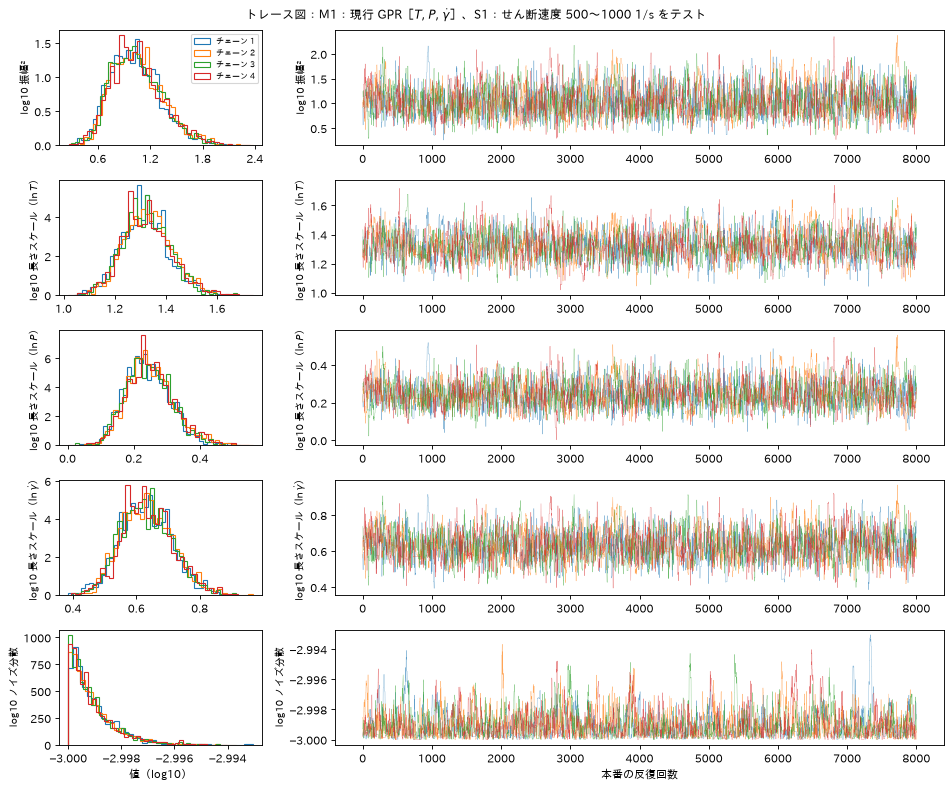

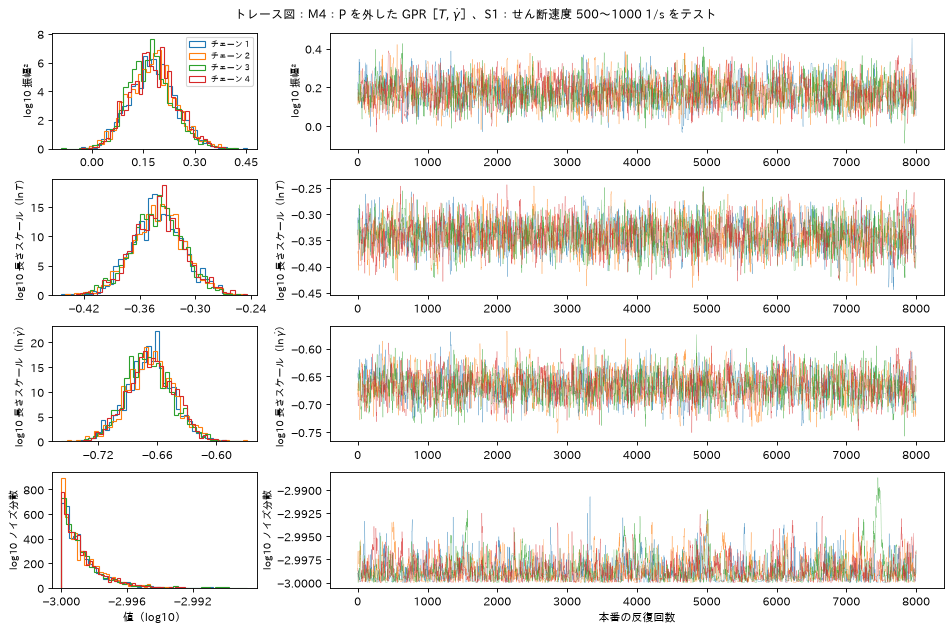

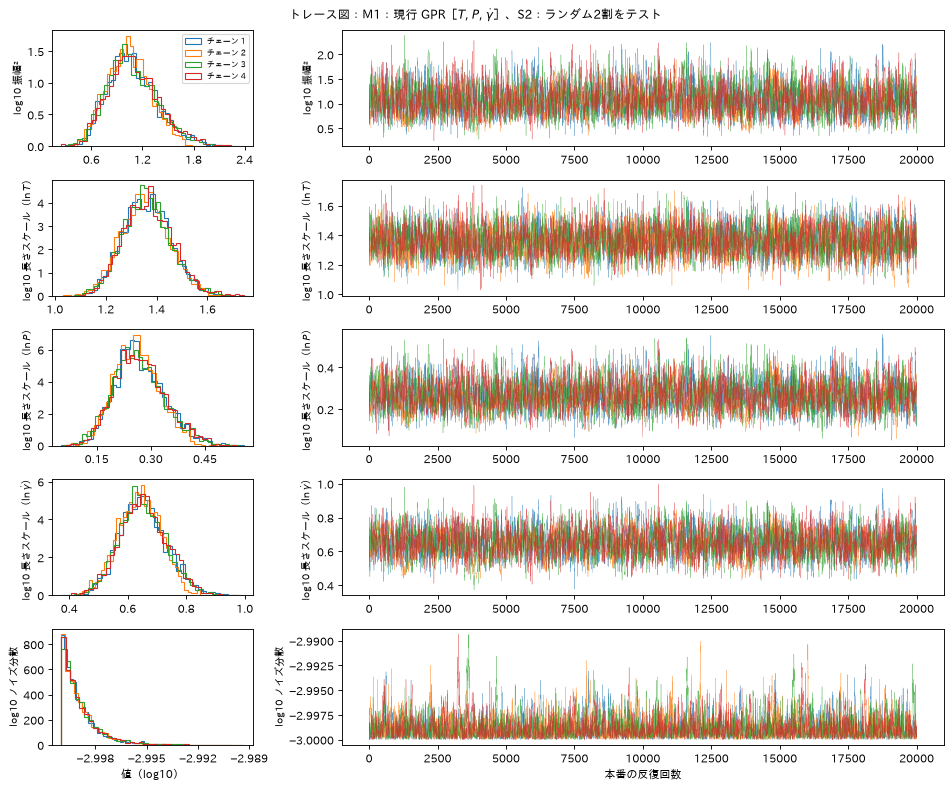

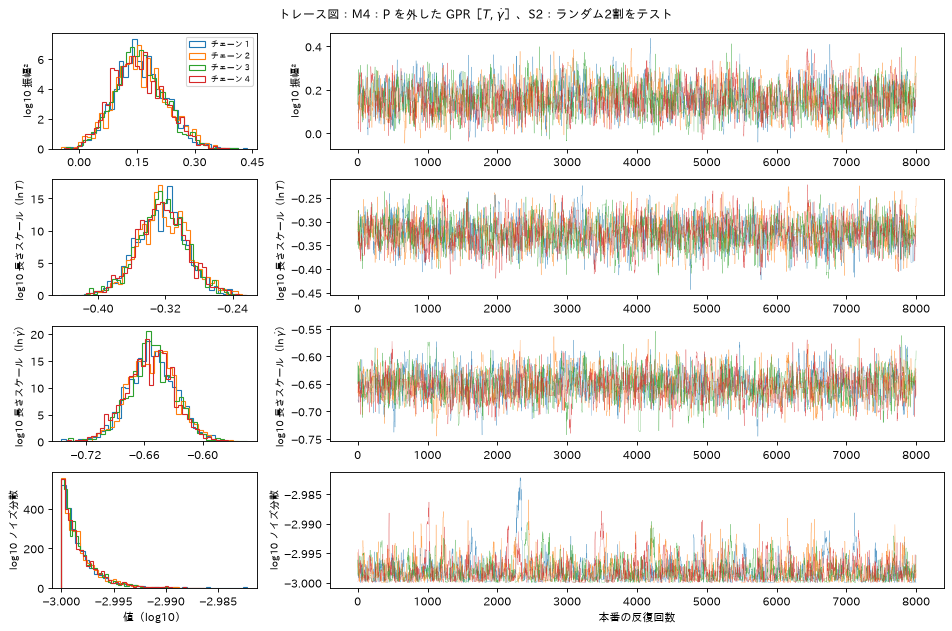

In [8]:
# セル8：トレース図（左：チェーンごとの分布、右：本番の推移。値は log10）
CHAIN_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
for (s, name), trace in traces.items():
    cols = theta_cols(name)
    fig, axes = plt.subplots(len(cols), 2, figsize=(12, 2.0 * len(cols)), gridspec_kw={"width_ratios": [1, 3]})
    for i, col in enumerate(cols):
        for ch, t in trace.groupby("chain"):
            v = t[col].to_numpy() / np.log(10)
            axes[i, 0].hist(v, bins=40, histtype="step", density=True, color=CHAIN_COLORS[ch % 4], label=f"チェーン {ch + 1}")
            axes[i, 1].plot(t["draw"], v, lw=0.3, alpha=0.7, color=CHAIN_COLORS[ch % 4])
        axes[i, 0].set_ylabel(f"log10 {PARAM_JA[col]}", fontsize=9)
        axes[i, 1].set_ylabel(f"log10 {PARAM_JA[col]}", fontsize=9)
        axes[i, 0].xaxis.set_major_locator(MaxNLocator(nbins=4))   # 目盛りの数字が重ならないように
    axes[0, 0].legend(fontsize=7)
    axes[-1, 0].set_xlabel("値（log10）")
    axes[-1, 1].set_xlabel("本番の反復回数")
    fig.suptitle(f"トレース図：{MODELS[name]['label']}、{SPLIT_LABELS[s]}", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"fig_trace_{s}_{name}.png"), dpi=FIG_DPI)
    plt.show()

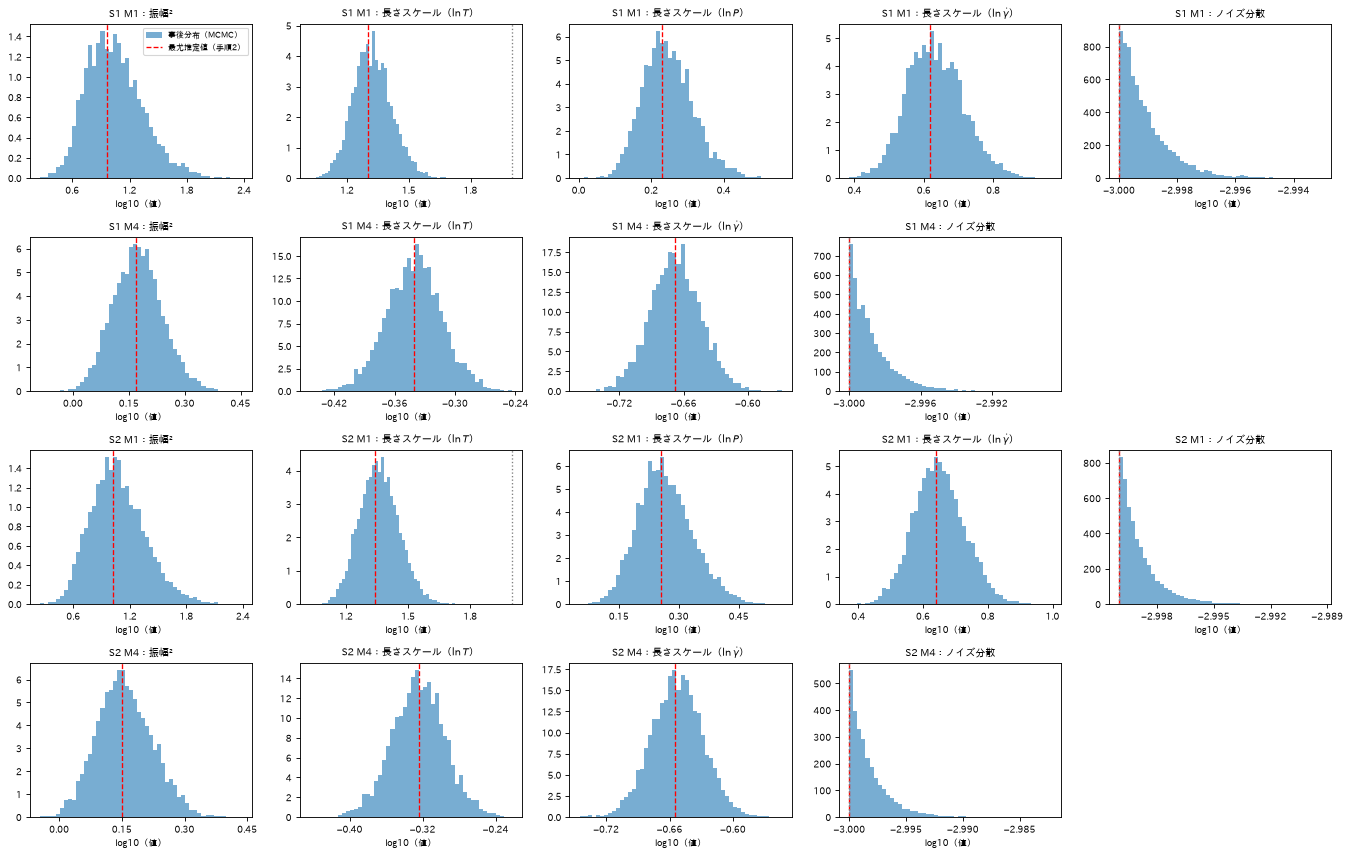

In [9]:
# セル9：事後分布と最尤推定値（赤の破線）。灰色の点線は事前分布の範囲の端
keys = list(traces)
n_col = max(len(theta_cols(name)) for _, name in keys)
fig, axes = plt.subplots(len(keys), n_col, figsize=(3.4 * n_col, 2.7 * len(keys)))
for i, (s, name) in enumerate(keys):
    cols, th_mle = theta_cols(name), mle_theta(s, name)
    for j in range(n_col):
        ax = axes[i, j]
        if j >= len(cols):
            ax.axis("off")
            continue
        col = cols[j]
        v = traces[(s, name)][col].to_numpy() / np.log(10)
        ax.hist(v, bins=50, density=True, color="tab:blue", alpha=0.6, label="事後分布（MCMC）")
        ax.axvline(th_mle[j] / np.log(10), color="red", ls="--", lw=1.2, label="最尤推定値（手順2）")
        key = "c" if col == "log_c" else ("noise" if col == "log_noise" else "ls")
        for b in BOUNDS[key]:
            if v.min() - 0.3 < np.log10(b) < v.max() + 0.3:
                ax.axvline(np.log10(b), color="gray", ls=":", lw=1.2, label="事前分布の範囲の端")
        ax.set_title(f"{s} {name}：{PARAM_JA[col]}", fontsize=9)
        ax.set_xlabel("log10（値）", fontsize=8)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))   # 目盛りの数字が重ならないように
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_posterior_vs_mle.png"), dpi=FIG_DPI)
plt.show()

## 5. 予測と評価（2つの分割 × 4つのモデル）

- MCMC：事後サンプルを等間隔に200個選び、各サンプルの GPR の予測分布（ノイズ込み）を混ぜる。予測平均は混合の平均、95%区間の被覆率は混合分布の累積分布、NLPD は混合分布の密度で計算する。
- MLE：手順2の最尤推定値1つで予測する（手順2の結果と一致することを確かめる）。
- `mean_pred_sd` は、テストデータでの予測標準偏差（ln η）の平均。予測区間の広さの目安。

In [10]:
# セル10：予測と評価
results, preds = [], {}
for s, te in SPLITS.items():
    tr = ~te
    for name, spec in MODELS.items():
        X = spec["X"]
        if spec["kind"] == "gpr":
            trace = traces[(s, name)].sort_values(["chain", "draw"])
            idx = np.linspace(0, len(trace) - 1, N_PRED_DRAWS).round().astype(int)
            thetas = trace[theta_cols(name)].to_numpy()[idx]
            t0 = time.time()
            mus, sds = gp_predict_thetas(X[tr], y_c[tr], X[te], thetas)
            preds[(s, name, "MCMC")] = (ln_eta[te], mus + y_mean, sds)
            results.append({"split": s, "model": name, "method": "MCMC", **evaluate_mixture(ln_eta[te], mus + y_mean, sds)})
            mu1, sd1 = gp_predict_thetas(X[tr], y_c[tr], X[te], mle_theta(s, name))
            preds[(s, name, "MLE")] = (ln_eta[te], mu1 + y_mean, sd1)
            results.append({"split": s, "model": name, "method": "MLE", **evaluate_mixture(ln_eta[te], mu1 + y_mean, sd1)})
            print(f"{s} {name}: 予測 {time.time() - t0:.0f} 秒")
        else:
            mu1, sd1 = predict_ols(fit_ols(X[tr], ln_eta[tr]), X[te])
            preds[(s, name, "OLS")] = (ln_eta[te], mu1[None, :], sd1[None, :])
            results.append({"split": s, "model": name, "method": "OLS", **evaluate_mixture(ln_eta[te], mu1, sd1)})
metrics_df = pd.DataFrame(results)
metrics_df.to_csv(os.path.join(OUT_DIR, "metrics.csv"), index=False, encoding="utf-8-sig")

# 最尤推定（MLE）と線形回帰の結果が手順2と一致するかの確認
step2 = pd.read_csv(os.path.join(STEP2_DIR, "metrics.csv"))
chk = metrics_df[metrics_df["method"] != "MCMC"].merge(step2, on=["split", "model"], suffixes=("", "_step2"))
max_diff = max(np.abs(chk[c] - chk[f"{c}_step2"]).max() for c in ["R2_ln_eta", "RMSE_ln_eta", "R2_eta", "coverage95", "NLPD"])
print(f"MLE・OLS の指標と手順2の差の最大値: {max_diff:.2e}")

print("\n【テストデータでの指標】（ln は自然対数。R2_eta は粘度の実数値で計算）")
print(metrics_df.round(4).to_string(index=False))

S1 M1: 予測 42 秒
S1 M4: 予測 39 秒
S2 M1: 予測 32 秒
S2 M4: 予測 34 秒
MLE・OLS の指標と手順2の差の最大値: 1.51e-13

【テストデータでの指標】（ln は自然対数。R2_eta は粘度の実数値で計算）
split model method  R2_ln_eta  RMSE_ln_eta  R2_eta  coverage95    NLPD  mean_pred_sd
   S1    M1   MCMC     0.9823       0.0476  0.9666      1.0000 -1.7788        0.0581
   S1    M1    MLE     0.9823       0.0476  0.9666      1.0000 -1.7809        0.0565
   S1    M2    OLS     0.8200       0.1517  0.8794      0.7889 -0.3563        0.1124
   S1    M3    OLS     1.0000       0.0000  1.0000      1.0000 -8.4602        0.0001
   S1    M4   MCMC    -2.6895       0.6866 -1.6485      1.0000  1.1770        1.0626
   S1    M4    MLE    -2.6793       0.6856 -1.6440      1.0000  1.1729        1.0548
   S2    M1   MCMC     0.9999       0.0110  1.0000      1.0000 -2.4378        0.0330
   S2    M1    MLE     0.9999       0.0110  1.0000      1.0000 -2.4394        0.0329
   S2    M2    OLS     0.9932       0.1120  0.9627      0.9574 -0.7695        0.1159
   S2    M3    O

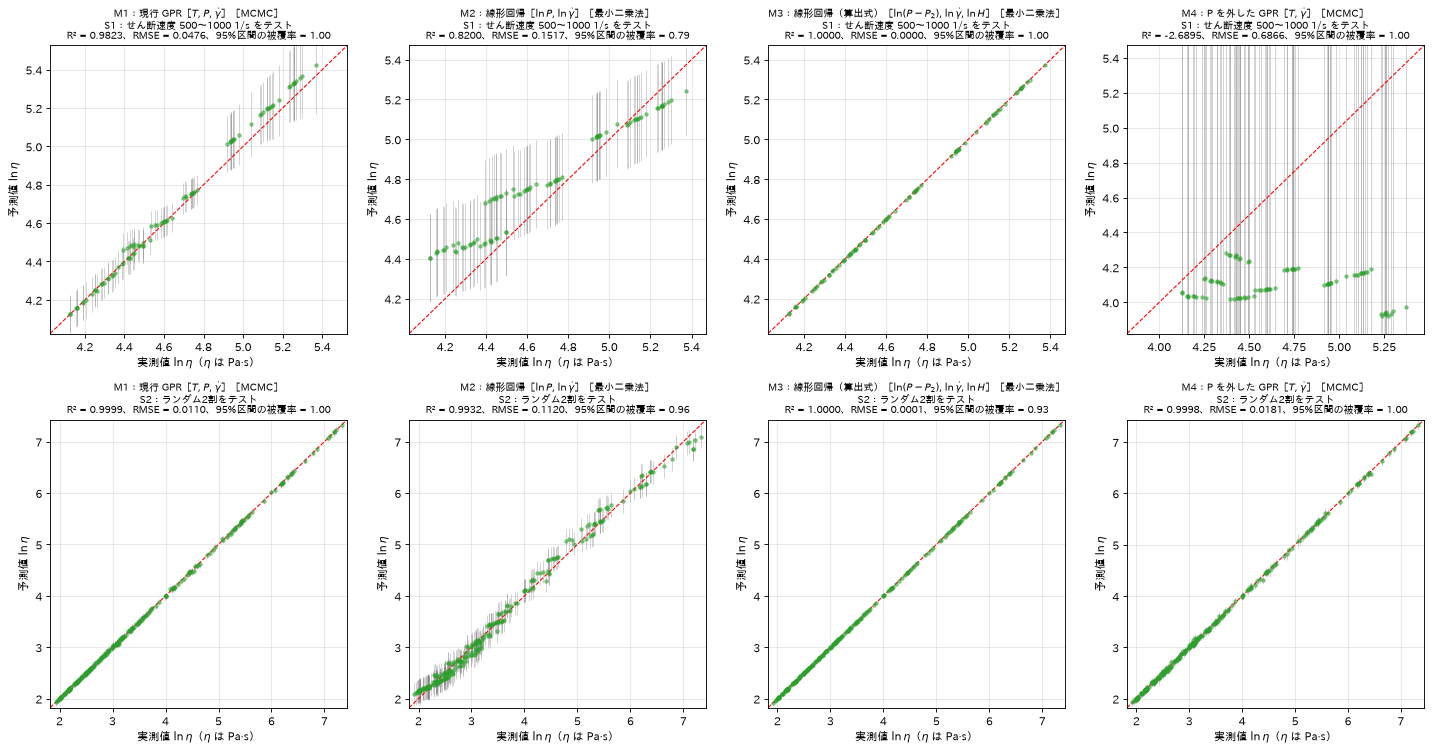

In [11]:
# セル11：パリティ図（MCMC 版。縦棒は混合予測分布の ±1.96σ）
METHOD_JA = {"MCMC": "MCMC", "OLS": "最小二乗法"}
fig, axes = plt.subplots(2, 4, figsize=(18, 9.5))
for i, s in enumerate(SPLITS):
    for j, name in enumerate(MODELS):
        ax = axes[i, j]
        method = "MCMC" if MODELS[name]["kind"] == "gpr" else "OLS"
        y_t, mus, sds = preds[(s, name, method)]
        mu = mus.mean(axis=0)
        sd = np.sqrt((sds ** 2 + mus ** 2).mean(axis=0) - mu ** 2)
        ax.errorbar(y_t, mu, yerr=1.96 * sd, fmt="o", ms=3, alpha=0.5, elinewidth=0.6, color="tab:green", ecolor="gray")
        lo, hi = min(y_t.min(), mu.min()) - 0.1, max(y_t.max(), mu.max()) + 0.1
        ax.plot([lo, hi], [lo, hi], "r--", lw=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        r = metrics_df.query("split == @s and model == @name and method == @method").iloc[0]
        ax.set_title(f"{MODELS[name]['label']}［{METHOD_JA[method]}］\n{SPLIT_LABELS[s]}\n"
                     f"R² = {r['R2_ln_eta']:.4f}、RMSE = {r['RMSE_ln_eta']:.4f}、95%区間の被覆率 = {r['coverage95']:.2f}", fontsize=9)
        ax.set_xlabel(r"実測値 $\ln\eta$（$\eta$ は Pa·s）")
        ax.set_ylabel(r"予測値 $\ln\eta$")
        ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_parity_ln_eta_mcmc.png"), dpi=FIG_DPI)
plt.show()

## 6. 現行モデル M1 の予測曲線（P を中央値に固定し、流動先端温度だけを変える）

実線と帯は MCMC（混合予測分布の平均と ±1.96σ）、破線は最尤推定（手順2の図4と同じ）。

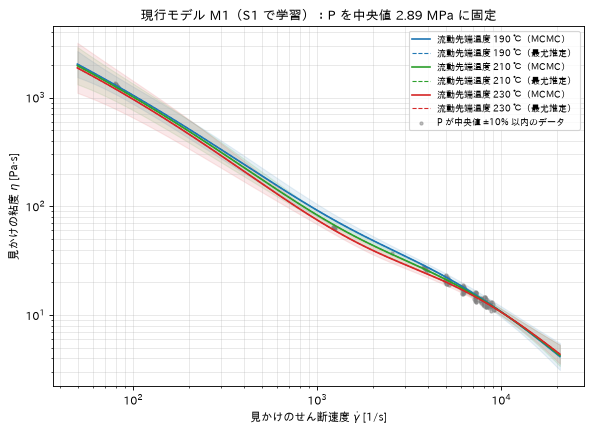

流動先端温度 190 ℃: ln η–ln γ̇ の傾き -0.987（P が中央値のショットがある γ̇ の範囲）
流動先端温度 210 ℃: ln η–ln γ̇ の傾き -0.992（P が中央値のショットがある γ̇ の範囲）
流動先端温度 230 ℃: ln η–ln γ̇ の傾き -0.992（P が中央値のショットがある γ̇ の範囲）
190 ℃ と 230 ℃ の曲線の差: ln η で最大 0.217（粘度の比 1.24）、平均 0.142


In [12]:
# セル12：M1（S1 で学習）の予測曲線
T_COLORS = {190.0: "tab:blue", 210.0: "tab:green", 230.0: "tab:red"}
tr = ~SPLITS["S1"]
X_tr, y_tr = MODELS["M1"]["X"][tr], y_c[tr]
trace = traces[("S1", "M1")].sort_values(["chain", "draw"])
idx = np.linspace(0, len(trace) - 1, N_PRED_DRAWS).round().astype(int)
thetas = trace[theta_cols("M1")].to_numpy()[idx]
P_fix = np.median(P)
sr_grid = np.geomspace(sr.min(), sr.max(), 200)
near = np.abs(np.log(P / P_fix)) < np.log(1.1)       # P が中央値の ±10% 以内のショット
in_range = (sr_grid >= sr[near].min()) & (sr_grid <= sr[near].max())
fig, ax = plt.subplots(figsize=(7.5, 5.5))
curves = {}
for t in [190.0, 210.0, 230.0]:
    Xg = sc_M1.transform(np.column_stack([np.full_like(sr_grid, np.log(t + 273.15)), np.full_like(sr_grid, np.log(P_fix)), np.log(sr_grid)]))
    mus, sds = gp_predict_thetas(X_tr, y_tr, Xg, thetas)
    mu_c = mus.mean(axis=0)
    sd = np.sqrt((sds ** 2 + mus ** 2).mean(axis=0) - mu_c ** 2)
    mu = mu_c + y_mean
    mu_mle, _ = gp_predict_thetas(X_tr, y_tr, Xg, mle_theta("S1", "M1"))
    curves[t] = mu
    ax.plot(sr_grid, np.exp(mu), color=T_COLORS[t], label=f"流動先端温度 {t:.0f} ℃（MCMC）")
    ax.fill_between(sr_grid, np.exp(mu - 1.96 * sd), np.exp(mu + 1.96 * sd), color=T_COLORS[t], alpha=0.1)
    ax.plot(sr_grid, np.exp(mu_mle[0] + y_mean), color=T_COLORS[t], ls="--", lw=1, label=f"流動先端温度 {t:.0f} ℃（最尤推定）")
ax.scatter(sr[near], eta[near], s=8, color="gray", alpha=0.5, label="P が中央値 ±10% 以内のデータ")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"見かけのせん断速度 $\dot{\gamma}$ [1/s]")
ax.set_ylabel(r"見かけの粘度 $\eta$ [Pa·s]")
ax.set_title(f"現行モデル M1（S1 で学習）：P を中央値 {P_fix / 1e6:.2f} MPa に固定")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_M1_curves_by_T_mcmc.png"), dpi=FIG_DPI)
plt.show()

for t, c in curves.items():
    slope = np.polyfit(np.log(sr_grid[in_range]), c[in_range], 1)[0]
    print(f"流動先端温度 {t:.0f} ℃: ln η–ln γ̇ の傾き {slope:.3f}（P が中央値のショットがある γ̇ の範囲）")
diff = np.abs(curves[190.0][in_range] - curves[230.0][in_range])
print(f"190 ℃ と 230 ℃ の曲線の差: ln η で最大 {diff.max():.3f}（粘度の比 {np.exp(diff.max()):.2f}）、平均 {diff.mean():.3f}")

## 7. まとめ

In [13]:
# セル13：主要な数値と保存したファイル
pivot = metrics_df.pivot_table(index=["model", "method"], columns="split",
                               values=["R2_ln_eta", "RMSE_ln_eta", "coverage95", "NLPD", "mean_pred_sd"])
print(pivot.round(4).to_string())
print("\n保存したファイル:")
for f in sorted(os.listdir(OUT_DIR)):
    print("  ", os.path.normpath(os.path.join(OUT_DIR, f)))

                NLPD         R2_ln_eta         RMSE_ln_eta         coverage95         mean_pred_sd        
split             S1      S2        S1      S2          S1      S2         S1      S2           S1      S2
model method                                                                                              
M1    MCMC   -1.7788 -2.4378    0.9823  0.9999      0.0476  0.0110     1.0000  1.0000       0.0581  0.0330
      MLE    -1.7809 -2.4394    0.9823  0.9999      0.0476  0.0110     1.0000  1.0000       0.0565  0.0329
M2    OLS    -0.3563 -0.7695    0.8200  0.9932      0.1517  0.1120     0.7889  0.9574       0.1124  0.1159
M3    OLS    -8.4602 -8.0632    1.0000  1.0000      0.0000  0.0001     1.0000  0.9302       0.0001  0.0001
M4    MCMC    1.1770 -2.2766   -2.6895  0.9998      0.6866  0.0181     1.0000  0.9961       1.0626  0.0364
      MLE     1.1729 -2.2789   -2.6793  0.9998      0.6856  0.0181     1.0000  0.9961       1.0548  0.0363

保存したファイル:
   ..\results\step2_mcmc\c